## 1. Raw Data
Loading the F1 Pit Strategy dataset.

In [10]:
import pandas as pd
import numpy as np
import os

# Load data
data_path = '/kaggle/input/competitions/playground-series-s6e5'
train = pd.read_csv(f'{data_path}/train.csv')
test = pd.read_csv(f'{data_path}/test.csv')
print(f'Train shape: {train.shape}')
print(f'Test shape: {test.shape}')

Train shape: (439140, 16)
Test shape: (188165, 15)


## 2. Data Validation
Checking for missing values and inspecting data types.

In [11]:
print('Missing values in Train:')
print(train.isnull().sum())
print('\nData Types:')
print(train.dtypes)

Missing values in Train:
id                        0
Driver                    0
Compound                  0
Race                      0
Year                      0
PitStop                   0
LapNumber                 0
Stint                     0
TyreLife                  0
Position                  0
LapTime (s)               0
LapTime_Delta             0
Cumulative_Degradation    0
RaceProgress              0
Position_Change           0
PitNextLap                0
dtype: int64

Data Types:
id                          int64
Driver                     object
Compound                   object
Race                       object
Year                        int64
PitStop                     int64
LapNumber                   int64
Stint                       int64
TyreLife                  float64
Position                    int64
LapTime (s)               float64
LapTime_Delta             float64
Cumulative_Degradation    float64
RaceProgress              float64
Position_Change          

## 3. Exploratory Data Analysis (EDA) - Correlation & Importance
Identifying redundant features and visualizing model priorities.

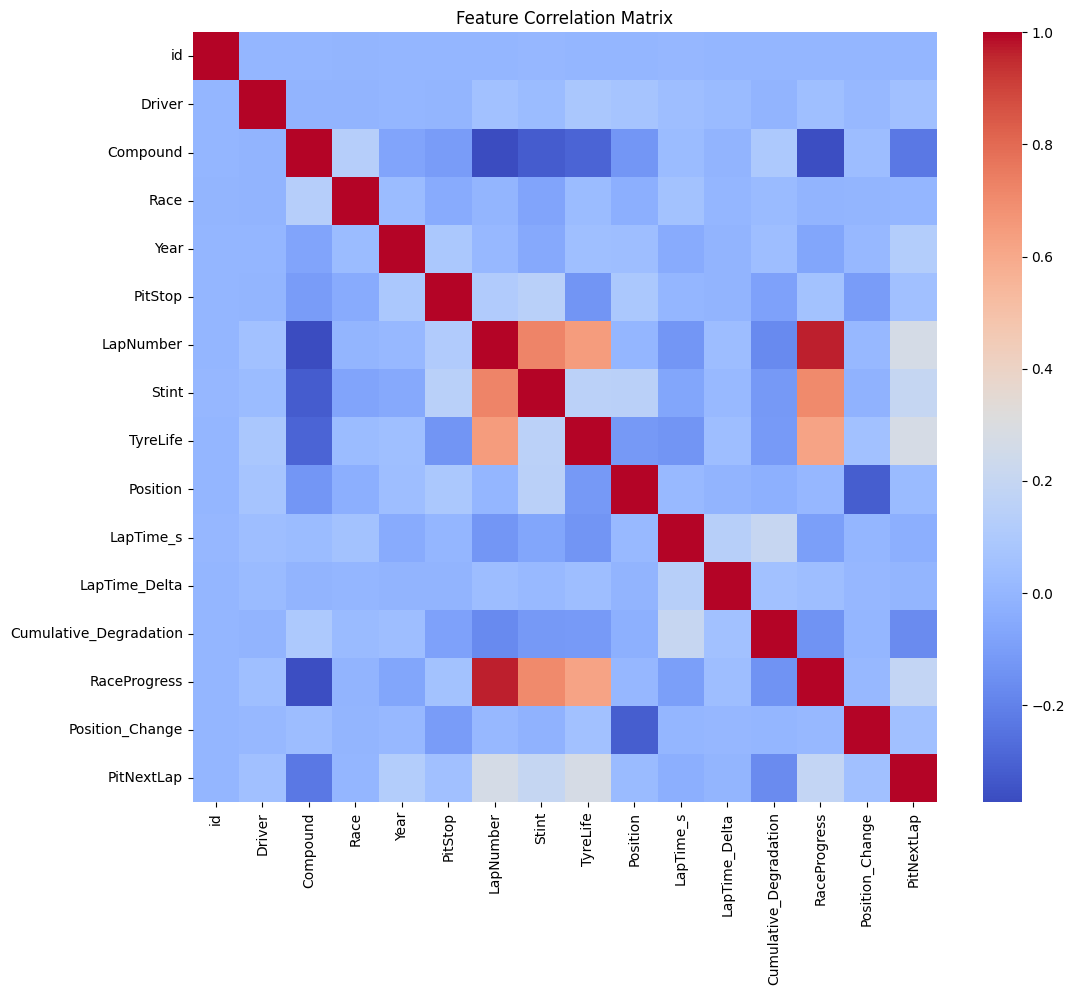

Highly correlated features (>0.95): ['RaceProgress']


In [12]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import OrdinalEncoder

# Pre-processing for EDA (required to get numeric correlations)
train_eda = train.copy()
train_eda.columns = [c.replace(' ', '_').replace('(', '').replace(')', '').replace('[', '').replace(']', '') for c in train_eda.columns]

cat_cols = ['Driver', 'Compound', 'Race']
encoder = OrdinalEncoder()
train_eda[cat_cols] = encoder.fit_transform(train_eda[cat_cols].astype(str))

# Correlation Heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(train_eda.corr(), annot=False, cmap='coolwarm')
plt.title('Feature Correlation Matrix')
plt.show()

# High Correlation Check (e.g. LapNumber vs RaceProgress)
corr_matrix = train_eda.corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
to_drop = [column for column in upper.columns if any(upper[column] > 0.95)]
print(f'Highly correlated features (>0.95): {to_drop}')

## 4. Data Preprocessing & Feature Engineering
Implementing all features from Experiment 3 and then performing pruning.

In [13]:
from sklearn.preprocessing import OrdinalEncoder
from sklearn.model_selection import StratifiedKFold

# Clean column names
train.columns = [c.replace(' ', '_').replace('(', '').replace(')', '').replace('[', '').replace(']', '') for c in train.columns]
test.columns = [c.replace(' ', '_').replace('(', '').replace(')', '').replace('[', '').replace(']', '') for c in test.columns]

# --- Progressive Features (from Exp 2 & 3) ---
bins = [0, 3, 6, 10, 15, 20, 30, 40, 100]
for df in [train, test]:
    df['TyreLifeBin'] = pd.cut(df['TyreLife'], bins=bins, labels=False)
    df['PitWindowPressure'] = df['TyreLife'] * df['RaceProgress']
    df['Deg_diff'] = df.groupby(['Driver', 'Stint'])['Cumulative_Degradation'].diff().fillna(0)
    df['is_2023'] = (df['Year'] == 2023).astype(int)

# OOF Target Encoding for Driver
train['Driver_TE'] = 0
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
for train_idx, val_idx in skf.split(train, train['PitNextLap']):
    X_t, X_v = train.iloc[train_idx], train.iloc[val_idx]
    means = X_t.groupby('Driver')['PitNextLap'].mean()
    train.loc[val_idx, 'Driver_TE'] = train.loc[val_idx, 'Driver'].map(means)
train['Driver_TE'] = train['Driver_TE'].fillna(train['PitNextLap'].mean())
test['Driver_TE'] = test['Driver'].map(train.groupby('Driver')['PitNextLap'].mean())
test['Driver_TE'] = test['Driver_TE'].fillna(train['PitNextLap'].mean())

# Ordinal Encoding
cat_cols = ['Driver', 'Compound', 'Race']
encoder = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
train[cat_cols] = encoder.fit_transform(train[cat_cols].astype(str))
test[cat_cols] = encoder.transform(test[cat_cols].astype(str))

# --- Experiment 4: Pruning ---
# We observed high correlation between LapNumber and RaceProgress (RaceProgress is normalized and usually better for trees).
# We also drop 'Year' because 'is_2023' captures the main variance and Year might overfit.
drop_cols = ['id', 'PitNextLap', 'LapNumber', 'Year']
X = train.drop(drop_cols, axis=1)
y = train['PitNextLap']
test_X = test.drop([c for c in drop_cols if c in test.columns], axis=1)

print(f'Pruned features: {X.columns.tolist()}')

/tmp/ipykernel_57/423300689.py:22: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[0.19220779 0.21972318 0.16563147 ... 0.                nan        nan]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  train.loc[val_idx, 'Driver_TE'] = train.loc[val_idx, 'Driver'].map(means)


Pruned features: ['Driver', 'Compound', 'Race', 'PitStop', 'Stint', 'TyreLife', 'Position', 'LapTime_s', 'LapTime_Delta', 'Cumulative_Degradation', 'RaceProgress', 'Position_Change', 'TyreLifeBin', 'PitWindowPressure', 'Deg_diff', 'is_2023', 'Driver_TE']


## 5. Model Training
Training LightGBM on the pruned feature set.

In [14]:
import lightgbm as lgb

params = {
    'objective': 'binary',
    'metric': 'auc',
    'verbosity': -1,
    'device': 'gpu',
    'random_state': 42
}

try:
    temp_X = np.random.rand(10, X.shape[1])
    temp_y = np.random.randint(0, 2, 10)
    lgb.train(params, lgb.Dataset(temp_X, label=temp_y), num_boost_round=1)
    print('Using GPU for LightGBM')
except:
    params['device'] = 'cpu'
    print('Using CPU fallback')

Using GPU for LightGBM


## 6. Model Evaluation & Feature Importance
Visualizing which features provide the most signal after pruning.

ROC-AUC on hold-out set: 0.942226625834121


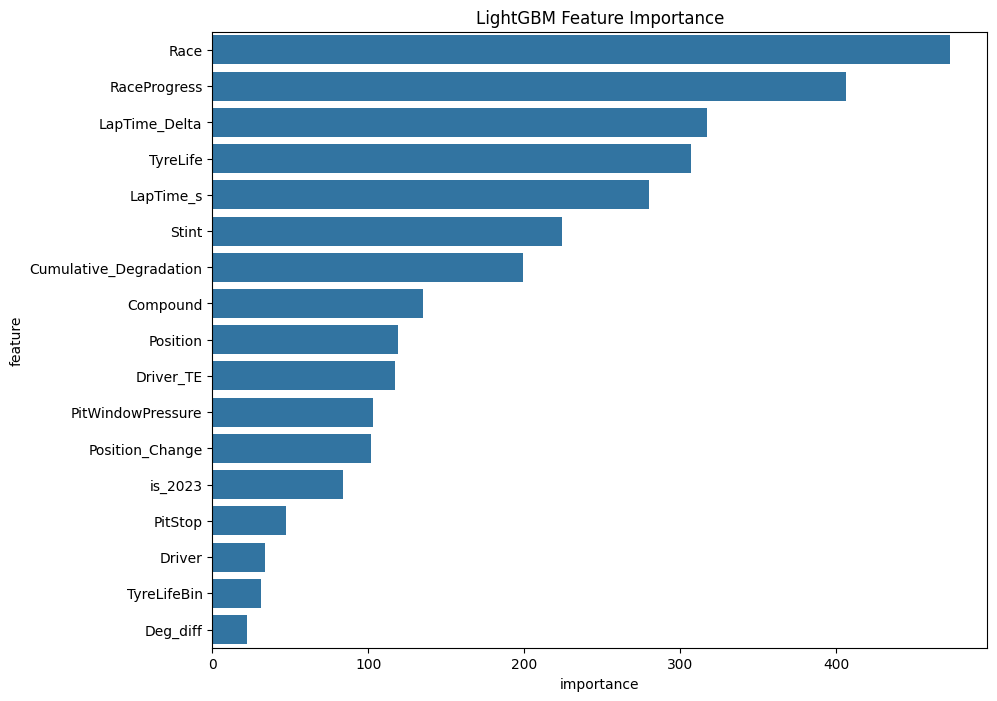

In [15]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

eval_model = lgb.LGBMClassifier(**params)
eval_model.fit(X_train, y_train)

val_preds = eval_model.predict_proba(X_val)[:, 1]
print(f'ROC-AUC on hold-out set: {roc_auc_score(y_val, val_preds)}')

# Feature Importance Plot
importances = pd.DataFrame({'feature': X.columns, 'importance': eval_model.feature_importances_})
importances = importances.sort_values('importance', ascending=False)
plt.figure(figsize=(10, 8))
sns.barplot(x='importance', y='feature', data=importances)
plt.title('LightGBM Feature Importance')
plt.show()

## 7. Model Validation
5-Fold Stratified Cross-Validation for stability check.

In [16]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
aucs = []
for fold, (train_idx, val_idx) in enumerate(skf.split(X, y)):
    X_t, X_v = X.iloc[train_idx], X.iloc[val_idx]
    y_t, y_v = y.iloc[train_idx], y.iloc[val_idx]
    m = lgb.LGBMClassifier(**params)
    m.fit(X_t, y_t)
    auc = roc_auc_score(y_v, m.predict_proba(X_v)[:, 1])
    aucs.append(auc)
    print(f'Fold {fold+1} AUC: {auc}')

print(f'\nMean AUC: {np.mean(aucs):.5f} +/- {np.std(aucs):.5f}')

Fold 1 AUC: 0.9422188966401072
Fold 2 AUC: 0.9407405186549611
Fold 3 AUC: 0.9418780793392444
Fold 4 AUC: 0.9408714017158488
Fold 5 AUC: 0.9413451808765397

Mean AUC: 0.94141 +/- 0.00057


## 8. Model Deployment & Feedback
Saving artifacts for Experiment 4.

In [17]:
import pickle
final_model = lgb.LGBMClassifier(**params)
final_model.fit(X, y)
with open('lgbm_experiment4.pkl', 'wb') as f:
    pickle.dump(final_model, f)
submission = pd.DataFrame({'id': test['id'], 'PitNextLap': final_model.predict_proba(test_X)[:, 1]})
submission.to_csv('submission.csv', index=False)
print('Saved lgbm_experiment4.pkl and submission_exp4.csv')

Saved lgbm_experiment4.pkl and submission_exp4.csv
